# EE 120 实验 3：快速傅里叶变换（FFT）

v1（演示版）- 2018 秋：Dominic Carrano  
v2 - 2019 春：Dominic Carrano, Babak Ayazifar  
v3 - 2019 秋：Dominic Carrano


In [1]:
from scipy import signal
import lab3_helper
import numpy as np
import matplotlib.pyplot as plt
import timeit, time
%matplotlib inline

### homework2
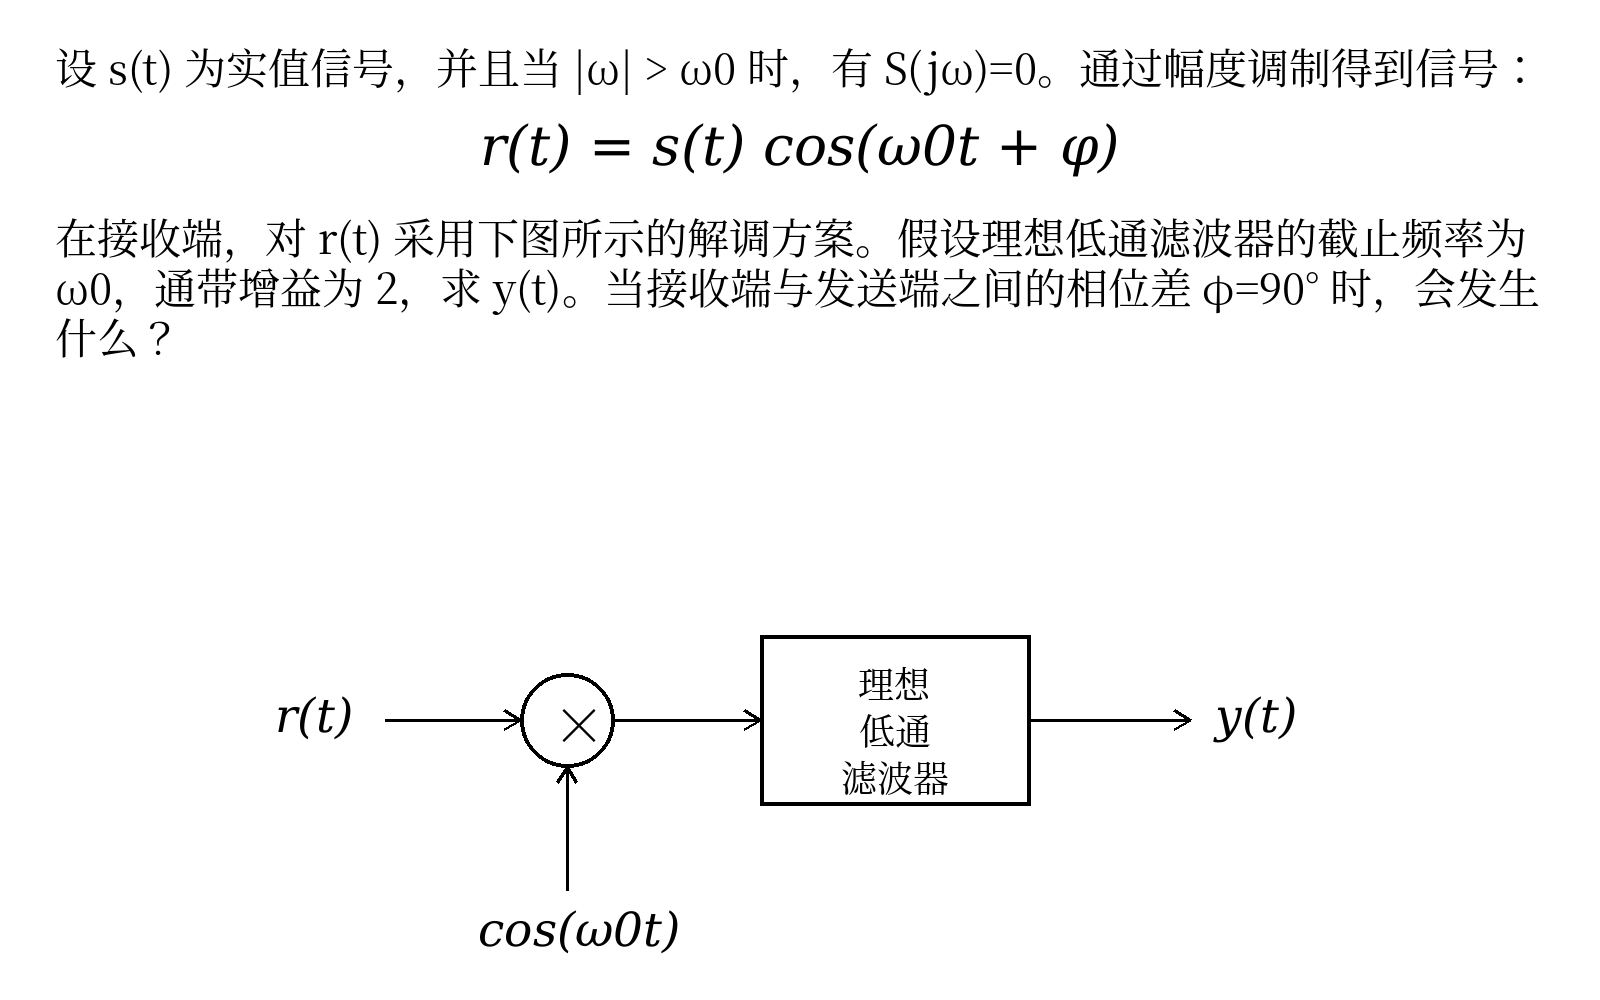


<StemContainer object of 3 artists>

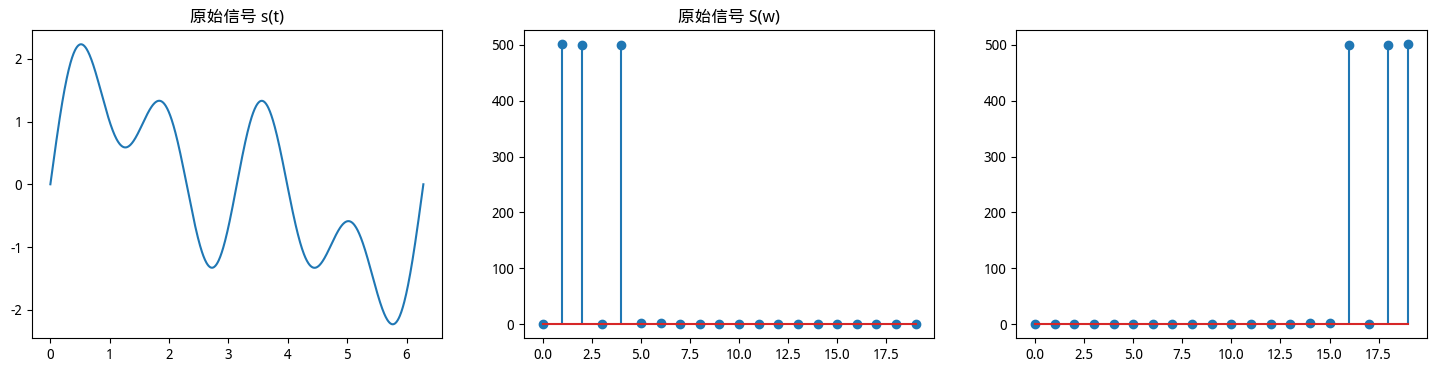

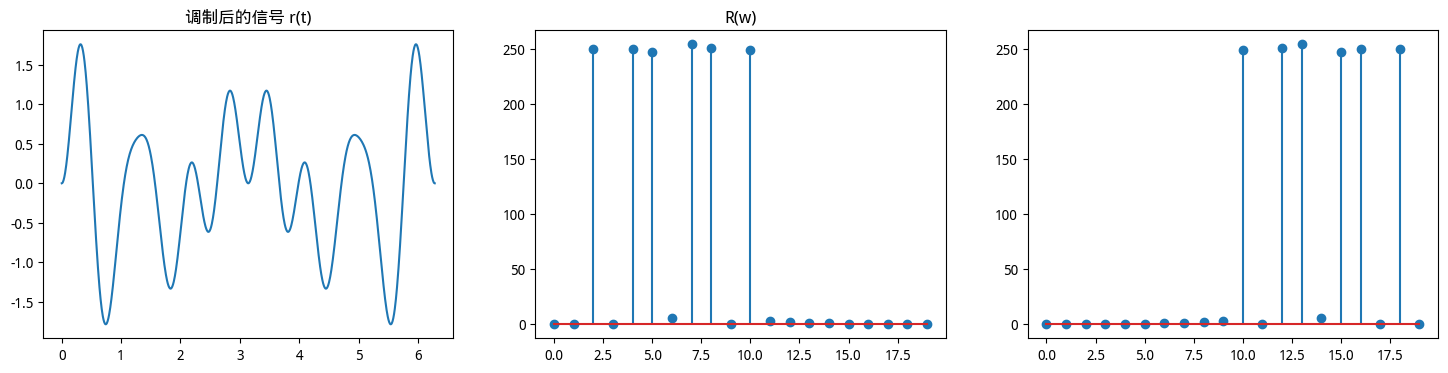

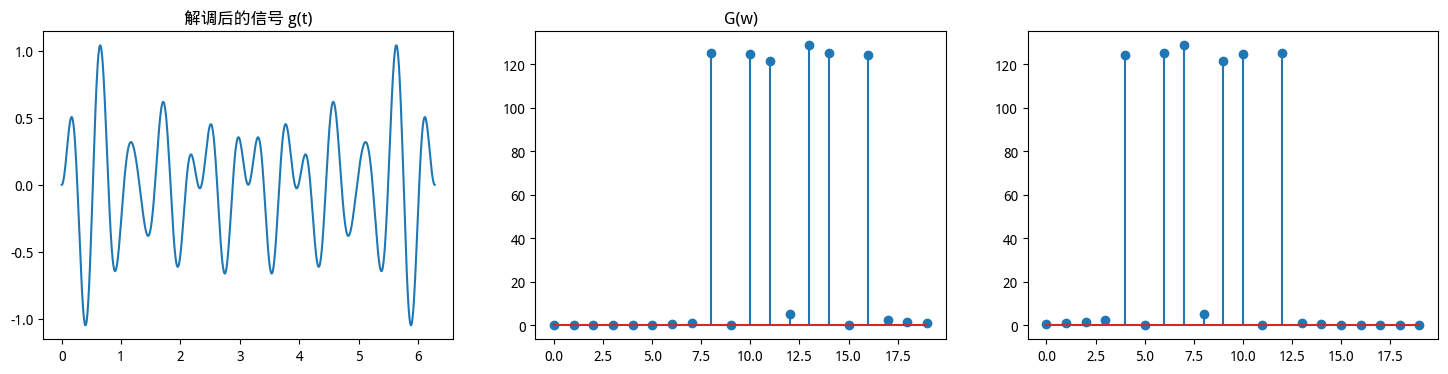

In [2]:
w_zeros = [1, 2, 4]
t = np.linspace(0, 2*np.pi, 1000)

# 获取 s(t)
s = np.zeros_like(t)
for w in w_zeros:
    s += np.sin(w*t)

plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
plt.title("原始信号 s(t)")
plt.plot(t, s)
s_ft = np.fft.fft(s)
plt.subplot(1, 3, 2)
plt.title("原始信号 S(w)")
plt.stem(np.abs(s_ft[:20]))
plt.subplot(1, 3, 3)
plt.stem(np.abs(s_ft[-20:]))

# 幅度调制
plt.figure(figsize=(18, 4))
r = s*np.sin(6*t)
plt.subplot(1, 3, 1)
plt.title("调制后的信号 r(t)")
plt.plot(t, r)
r_ft = np.fft.fft(r)
plt.subplot(1, 3, 2)
plt.title("R(w)")
plt.stem(np.abs(r_ft[:20]))
plt.subplot(1, 3, 3)
plt.stem(np.abs(r_ft[-20:]))

# 解调
plt.figure(figsize=(18, 4))
g = r*np.cos(6*t)
plt.subplot(1, 3, 1)
plt.title("解调后的信号 g(t)")
plt.plot(t, g)
g_ft = np.fft.fft(g)
plt.subplot(1, 3, 2)
plt.title("G(w)")
plt.stem(np.abs(g_ft[:20]))
plt.subplot(1, 3, 3)
plt.stem(np.abs(g_ft[-20:]))

In [3]:
np.fft?

Type:        module
String form: <module 'numpy.fft' from '/home/kernel/.conda/envs/EE_lab/lib/python3.14/site-packages/numpy/fft/__init__.py'>
File:        ~/.conda/envs/EE_lab/lib/python3.14/site-packages/numpy/fft/__init__.py
Docstring:  
Discrete Fourier Transform

.. currentmodule:: numpy.fft

The SciPy module `scipy.fft` is a more comprehensive superset
of `numpy.fft`, which includes only a basic set of routines.

Standard FFTs
-------------

.. autosummary::
   :toctree: generated/

   fft       Discrete Fourier transform.
   ifft      Inverse discrete Fourier transform.
   fft2      Discrete Fourier transform in two dimensions.
   ifft2     Inverse discrete Fourier transform in two dimensions.
   fftn      Discrete Fourier transform in N-dimensions.
   ifftn     Inverse discrete Fourier transform in N dimensions.

Real FFTs
---------

.. autosummary::
   :toctree: generated/

   rfft      Real discrete Fourier transform.
   irfft     Inverse real discrete Fourier transform.
   

# 背景

## 什么是 FFT？

本实验中，我们将实现快速傅里叶变换（Fast Fourier Transform，FFT）。FFT 是一种用来计算信号离散傅里叶变换（DFT）的算法。注意，DFT 和 FFT **不是** 两种不同的变换：FFT 只是实现 DFT 的一种具体算法，就像快速排序是排序数组的一种具体算法一样。你很可能以前在 Java 或 Python 中调用过库函数来排序数组，但大概率没有认真读过 [Java 的 `Arrays.sort` 源码](http://developer.classpath.org/doc/java/util/Arrays-source.html) 或 [Python 列表排序函数的源码](https://github.com/python/cpython/blob/master/Objects/listobject.c)。良好抽象的好处就在于：你不需要知道内部细节，只要调用 Java 中的 `Arrays.sort` 或 Python 中的 `sort`，剩下的都由库处理。类似地，在实际工程中，工程师通常不会关心 `numpy.fft.fft`（numpy 中计算 DFT 的函数）的内部实现，而是把它当作计算 DFT 的黑盒。不过在本实验中，你将有机会打开这个黑盒，自己实现一个 FFT，并把它与成熟实现进行比较。考虑到 FFT 在实际频谱分析中被极其广泛使用，而且还是卷积、互相关、图像和音频压缩等大量信号处理算法的高效实现基础，这件事非常值得做。


## 为什么高效计算 DFT 如此重要？

在深入之前，你可能会好奇 FFT 的动机：如果它只是计算 DFT，为什么这么重要？直接使用 DFT 分析公式真的那么慢吗？我们又为什么需要计算 DFT？这两个问题都值得回答。

### DFT 的重要性

你已经在“信号与系统”中见过傅里叶变换为什么重要：它让我们能够把信号分解成各个频率成分，从而更清楚地分析 LTI 系统的工作方式。但是，手算任意信号的频谱（也就是傅里叶变换）通常非常繁琐，甚至不可行。计算机更适合做这类任务。不过计算机也有限制，尤其是内存有限，因此不可能直接处理连续时间（CT）信号，因为它们包含无限多个取值。幸运的是，在一定条件下，我们可以对 CT 信号采样得到离散时间（DT）信号而不损失信息（后续课程会讲）。实际中我们关心的信号通常是有限时长的，或者可以截断成有限个数据点而不会造成明显信息损失。例如音频文件只包含由歌曲长度决定的有限个样本。因此，我们只需要考虑**有限时长**的 DT 信号，而这类信号是可以存入计算机的。

现在假设我们已经获得了一个有限时长的 DT 信号，并将它存储在 numpy 数组中，想看看它由哪些频率组成。自然地，我们似乎想计算它的 DTFT。但 DTFT 是频率的连续函数（虽然不像 CTFT，它是 $2\pi$ 周期的，但一个周期内仍然有无限多个值），所以我们又遇到了无法完整存储的问题。这正是 DFT 的用武之地：**长度为 $N$ 的信号，其 DFT 返回的是该信号 DTFT 的 $N$ 个均匀间隔采样点。** 为了说明这一点，我们把 DFT 与 DTFT 的分析公式并排比较：

$$\underbrace{X[k] = \sum_{n = 0}^{N - 1} x[n]e^{-j\frac{2\pi}{N}kn}}_{\text{DFT 分析}}\ \ \ \ \ \ \ \ \ \ \ \ \ \underbrace{X(e^{j\omega}) = \sum_{n = -\infty}^{\infty} x[n]e^{-j\omega n}}_{\text{DTFT 分析}}$$

如果假设信号恰好有 $N$ 个非零点（即持续时间为 $N$），那么 DTFT 分析公式的求和范围与 DFT 一致。进一步地，如果在 $N$ 个等间隔频率点 $\omega = 0, \frac{2\pi}{N}, \frac{2\pi \cdot 2}{N}, ..., \frac{2\pi \cdot (N-1)}{N}$ 上计算 DTFT，就会得到 DFT 分析公式给出的 $X[0], X[1], X[2], ..., X[N-1]$。**这就是 DFT 重要的原因：它是我们在计算机上计算信号频谱的基本方法。** 当然，仅用 DTFT 的 $N$ 个采样点是否足够表示它并不是显然的。在实践中，对信号补零会增大 $N$，也就是增加对 DTFT 的采样点数，从而得到更细的近似。这也是 EE 123 一开始会讲的内容之一：如果绘制频谱时分辨率不够，可以给信号补零。

关于 DFT 与 DTFT 之间关系的更形式化推导，请参考第 10 讲笔记。

### 多快才算“足够快”？

既然 DFT 如此重要，你可能会问：为什么仅靠 DFT 分析公式来计算会太慢？实际中，信号长度 $N$ 通常**至少**有几百，更常见的是 1000 或 10000 量级，具体应用中还可能更大。DFT 分析公式大约需要 $N^2$ 级别的计算（后面会分析原因）。而 FFT 只需要大约 $N\log N$ 级别的计算，快得多（事实上，当 $N$ 趋近于无穷大时，优势会无限增大）。等你等待朴素 DFT 函数运行时，就会直观体会到这种差别。


# Q1：朴素 DFT


## Q1a：DFT 代码

我们先用“朴素”的方式实现 DFT：直接把 DFT 分析公式翻译成代码。

如果有一个长度为 $N$ 的信号（在计算机中就是长度为 $N$ 的 numpy 数组），DFT 分析公式为：

$$X[k] = \sum_{n = 0}^{N-1} x[n] e^{-j\frac{2\pi}{N}nk}$$

其中 $k, n \in \{0, 1, 2, ..., N - 1\}$。一般来说，即使 $x[n]$ 是纯实数，$X[k]$ 也是复数数组。因此写代码时必须把输出类型声明为 `np.complex128`（两个 64 位浮点“实数”组成的复数，总共 128 位）。如果不这样做，numpy 在计算时会丢弃虚部，从而得到错误结果。

请在下面补全 `dft` 函数，根据分析公式计算 DFT。你输出的数组 `X` 中，`X[k], k = 0, 1, ..., N-1` 应该是第 `k` 个 DFT 系数的值。

**提示 1：** 函数调用 `np.exp(z)` 会返回 $e^z$，其中 $z$ 可以是实数也可以是复数。你以前可能只对实数或实数数组用过它，但它同样支持复数输入。  
**提示 2：** 在 Python 中，`1j` 表示复数 $j$。例如 Python 表达式 `1j * 2 * np.pi` 的值就是 $2\pi j$。如果忘了 `j` 前面的 `1`，Python 会以为你在引用名为 `j` 的变量，而不是虚数单位。


In [4]:
def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=np.complex128) # 输出数组
    ## TODO 在这里写代码 ##
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    ## TODO 在这里写代码 ##
    return X

我们先对朴素 DFT 函数做几个快速的正确性检查，确保它返回正确结果。运行下面的代码单元来检查你的实现。如果所有测试都没有打印 `True`，说明你的 `dft` 函数还有 bug。

第四和第五个测试可能需要半分钟左右（全部 5 个测试不应该超过 3-4 分钟），不用担心。这是因为我们写的是朴素 DFT 实现，对大输入会很慢。到本 notebook 结束时，我们会有很大改进；也希望这些测试能让你感受到 FFT 的价值，因为在真实世界中，1024 和 2048 是很常见的 FFT 数据块大小。


根据你电脑的处理能力，这个单元可能需要 30 秒到几分钟运行。这个单元只按正确性评分，不按运行时间评分。


In [5]:
lab3_helper.run_fft_tests(dft)

Test 1 passed: True
Test 2 passed: True
Test 3 passed: True
Test 4 passed: True
Test 5 passed: True
Tests took 9.48 seconds


## （可选）Q1b：DFT 计算量分析

为了完全理解朴素 DFT 算法，我们需要分析它执行了多少次运算。

回答下面的问题。这一部分完全可以通过观察 DFT 分析公式完成，不需要 Q1a 的实现能正常工作。也就是说，你应该基于分析公式作答，而不是基于你具体写出的代码（尽管二者应该一致）。


**Q：对于长度为 $N$ 的输入，`dft` 计算**单个** DFT 系数时执行多少次复数乘法？**

注：两个复数相乘算作一次乘法。例如，$x[1] \cdot e^{-j\frac{2\pi}{N}}$ 算作一次复数乘法，因为一般来说 $x[n]$ 的每个元素都是复数。


<span style="color:blue">**A：$N$**</span>


**Q：对于长度为 $N$ 的输入，`dft` 计算**单个** DFT 系数时执行多少次复数加法（两个复数相加）？**


<span style="color:blue">**A：$N-1$**</span>


**Q：把前两问答案相加，对于长度为 $N$ 的输入，计算单个 DFT 系数一共需要多少次复数运算（复数加法与复数乘法合计）？**


<span style="color:blue">**A：$2N-1$**</span>


**Q：再乘以系数个数 $N$，通过分析公式计算整个 DFT 一共需要多少次复数运算？**


<span style="color:blue">**A：$2N^2-N$**</span>


**Q：把上一问答案写成 Big-O 记号，通过分析公式计算 DFT 时，函数 `dft` 的渐近运行时间是多少？**

如果你还没学过 Big-O 记号，请在 Piazza 发帖或来 Office Hours 提问。


<span style="color:blue">**A：$O(N^2)$**</span>


# Q2：快速傅里叶变换

现在我们已经用“慢”的方式实现了 DFT，接下来用 FFT 来实现。FFT 算法主要分为两类：*时间抽取*（Decimation In Time，DIT）算法和 *频率抽取*（Decimation In Frequency，DIF）算法。它们都会利用计算中的冗余来减少运算量。DIT 的做法是把 $x[n]$ 分解成更小的信号，分别计算这些小信号的 DFT，再由这些小 DFT 构造出 $x[n]$ 的 DFT。DIF 则是把 $X[k]$ 分解成逐步变小的子序列，并在计算各部分系数的过程中组合出完整结果。

本实验中，我们将实现下面介绍的 DIT 算法。


## 算法

时间抽取（DIT）算法会把输入序列 $x[n]$ 分解成更小的子序列。它先把序列分成偶数编号样本和奇数编号样本，然后通过代数变形，构造出两个独立的 DFT：一个对应奇数下标的信号值，一个对应偶数下标的信号值。

下面的推导用到一个小技巧：当 $m$ 取不同值时，$2m$ 会生成偶数，而 $2m+1$ 会生成奇数（如果不确定，可以自己代几个值试一下）：

\begin{align}
    X[k] &= \sum_{n=0}^{N-1} x[n]e^{-j\frac{2\pi}{N}nk} \\
    &= \sum_{n\ \text{even}}x[n] e^{-j\frac{2\pi}{N}nk} + \sum_{n\ \text{odd}}x[n] e^{-j\frac{2\pi}{N}nk} \\
    &= \sum_{m = 0}^{N/2-1} x[2m] e^{-j\frac{2\pi}{N}(2m)k} + \sum_{m = 0}^{N/2-1} x[2m + 1] e^{-j\frac{2\pi}{N}(2m + 1)k} \\
    &= \left(\sum_{m = 0}^{N/2-1} x[2m] e^{-j\frac{2\pi}{N/2}mk}\right) + e^{-j\frac{2\pi}{N}k}\left(\sum_{m = 0}^{N/2-1} x[2m + 1] e^{-j\frac{2\pi}{N/2}mk}\right)\\
    &= E[k] + e^{-j\frac{2\pi}{N}k} O[k]
\end{align}

其中 $E[k]$ 是偶数下标 $x[n]$ 值的 $N/2$ 点 DFT，$O[k]$ 是奇数下标信号值的 $N/2$ 点 DFT。**由于 $E, O$ 的长度都是 $N/2$，而 $X$ 的长度是 $N$，所以索引必须按模 $N/2$ 来理解。** 例如，若是 4 点 DFT，则 $E,O$ 长度为 2，因此计算 $X[3]$ 时应写成 $X[3] = E[1] + e^{-j\frac{2\pi}{4}3} O[1]$，因为 $E[3],O[3]$ 并不存在。

这样，我们就得到了由 $E[k]$ 和 $O[k]$ 计算 DFT 系数 $X[k]$ 的公式。也就是说，长度 $N$ 的 DFT 问题被化成了两个长度 $N/2$ 的 DFT 问题。

## 实现细节

写代码时需要注意下面几点：
- 创建偶数下标和奇数下标信号时，按照它们的 DFT 分别叫作 $E[k]$ 与 $O[k]$ 的约定，把信号记作 $e[n]$ 和 $o[n]$。我们从长度为 $N$ 的信号 $x[n]$ 中构造两个长度为 $N/2$ 的信号：
    - $e[n]$ 保存 $x[0], x[2], x[4], ..., x[N/2]$。这里假设 $N$ 为偶数，因此 $N/2$ 是整数。
    - $o[n]$ 保存 $x[1], x[3], x[5], ..., x[(N/2) - 1]$。
- FFT 是递归算法。我们假设信号长度 $N$ 是 2 的幂，这样就总能把问题一分为二，直到长度为 1 的基本情况。后面会进一步讨论这一点。
- $X[k]$ 有 $N$ 个系数，而 $E[k]$ 和 $O[k]$ 各只有 $N/2$ 个。比如 $N=4$ 时，如果要算 $X[3]$，就要按模 $N/2$（这里是模 2）解释索引，因此访问 $E[1],O[1]$ 而不是不存在的 $E[3],O[3]$。**写代码时一定要处理好这一点。**
- 计算某个具体系数 $X[k]$ 时：
    - $O[k]$ 前面的 $e^{-j\frac{2\pi}{N}k}$ 只与单个系数 $O[k]$ 相乘，然后再加到单个系数 $E[k]$ 上。例如，$X[6] = E[6] + e^{-i\frac{12\pi}{N}}O[6]$。最简单的实现方式就是遍历 `k`，一次计算一个系数。


## 一个重要假设：$N$ 是 2 的幂

DIT FFT 算法的关键步骤之一，是把 $x[n]$ 分成大小相等的两部分 $e[n]$ 和 $o[n]$。FFT 是递归算法，会不断重复这种“拆分”，直到得到长度为 1 的信号。为了保证每一层都能平均分成两半，我们需要信号长度始终能被 2 整除，这只有当输入长度 $N$ 是 2 的幂时才一定成立。

如果输入长度不是 2 的幂，有两种处理方式：
1. 在信号末尾拼接 0，也就是“补零”，使其长度变为当前长度之后的下一个 2 的幂。补零会让 DTFT 的采样更细：根据本实验开头的背景部分，更大的 $N$ 意味着在 $2\pi$ 区间内采样更多点，因为 DFT 本质上就是在 $N$ 个均匀间隔点上采样 DTFT。事实上，补零常常不仅仅是为了计算效率，也用于获得更细的 DTFT 采样。例如长度为 926 的信号可以补零到 2048，虽然补到 1024 已经能获得效率提升，但补到 2048 可以看到更细的频谱插值。
2. 调用你写的朴素 DFT 函数 `dft`，这样可以得到精确请求长度的 DFT，但计算量更大。

这里我们采用第二种方式。这样使用我们 FFT 函数的人可以有更细的控制：如果他们想补零，可以在传入信号前自己补零。

这里介绍的 DIT FFT 算法称为 *radix-2* FFT，因为我们把问题分成两个大小为 $N/2$ 的递归子问题。因此我们假设输入长度是 2 的幂，这样就可以一直除以 2，直到达到长度 1 的基本情况，而不用担心不能整除。例如长度 14 的信号会被分成两个长度 7 的信号，而 7 无法再平均分成两半。

也存在其他基数的 FFT 算法，例如基数 3（此时会假设输入长度是 3 的幂，并做类似推导）、基数 5 等。成熟的 FFT 库函数（如 numpy 的实现）使用 *混合基数* FFT，把多种基数的算法组合在一起，从而在对长度要求较少的情况下仍能高效实现。本实验只考虑 radix-2 情况。


## Q2a：FFT 代码

请在 `my_fft` 函数中实现 DIT FFT 算法。如果输入数组 `x` 的长度不是 2 的幂，就直接调用 `dft`。如果觉得有帮助，可以使用已经提供的 `is_power_of_two` 函数；当然你不一定非要使用它，也不需要理解它的内部实现。

**提示 1：** FFT 是递归算法，基本情况是 $N=1$：这时只有一个信号值，也只需要计算一个 DFT 系数。分析公式告诉你，这个 DFT 系数 $X[0]$ 与唯一的信号值 $x[0]$ 是什么关系？不要想复杂。

**提示 2：** [Python 的切片功能](https://stackoverflow.com/questions/509211/understanding-slice-notation) 对提取偶数下标和奇数下标的信号分量非常有用。


In [6]:
def is_power_of_two(n):
    """Return if n is a power of 2, assuming n is a non-negative integer."""
    return n & (n - 1) == 0

In [7]:
def my_fft(x):
    """
    Decimation in time FFT algorithm.
    """
    N = len(x)
    X = np.zeros(N, dtype=np.complex128)

   
    ## TODO - 在这里实现 FFT ##
    if N == 1:
        X[0] = x[0]
        return X
    if not (is_power_of_two(N)):
        return dft(x)

    x_even=x[::2]
    x_odd=x[1::2]

    E=my_fft(x_even)
    O=my_fft(x_odd)

    for k in range(N // 2):
        W = np.exp(-2j * np.pi * k / N)
        X[k] = E[k] + W * O[k]
        X[k + N // 2] = E[k] - W * O[k]

    ## TODO ##
    return X


运行测试来验证正确性。如果 `my_fft` 实现正确，5 个测试都应该通过，而且几乎会立即完成。

你的实现会同时按速度和正确性评分。只要代码在几秒内完成就没问题。作为参考，教师版本几乎没有优化，基本就是按照上面推导写出的裸实现，在 2015 年的笔记本上跑完所有测试大约需要 1/4 秒。

调试时可以检查：
- *(正确性)* 记住，$E[k]$ 和 $O[k]$ 只有 $N/2$ 个元素，但我们要用它们计算总共 $N$ 个 DFT 系数。
- *(正确性)* 和 `dft` 中一样，确保输出数组 $X[k]$ 初始化为 `complex128` 类型，否则会丢掉虚部。
- *(速度)* 确认你判断 `x` 的长度是否为 2 的幂的条件正确；你可能在不需要的时候错误地调用了 `dft`。


In [8]:
lab3_helper.run_fft_tests(my_fft)

Test 1 passed: True
Test 2 passed: True
Test 3 passed: True
Test 4 passed: True
Test 5 passed: True
Tests took 0.024 seconds


## （可选）Q2b：FFT 计算量分析

我们已经从实验上看到 FFT 比 DFT 快得多。现在，我们把这种理解形式化，说明为什么会这样。


**Q：** FFT 是递归算法，每次递归调用都会把输入规模减半。计算 $N$ 点 FFT 时，假设 $N$ 是 2 的幂，总共有多少**层**递归？（等价地说，在到达长度为 1 的基本情况之前，$N$ 可以被 2 除多少次？）**答案应写成 $N$ 的函数。**


<span style="color:blue">**A：$\log(N)$** </span>


**Q：** 我们知道每次 FFT 递归调用都会产生两个新的递归调用（假设还没有到达基本情况）。在第 $k$ 层递归中，$k=0,1,...,?$，其中 $?$ 是上一问答案，这一层总共有多少个递归调用？说明：$k=0$ 对应最初的调用，此时只有 1 个调用；$k=1$ 有 2 个调用，由初始调用产生；依此类推。**答案应写成 $k$ 的函数。**


<span style="color:blue">**A：$2^k$** </span>


**Q：** 考虑第 $k$ 层递归中的某一次 FFT 调用。这一层 FFT 的输入大小是多少？**答案应写成 $k$ 和 $N$ 的函数。**（提示：每次输入规模都会减半，从 $N$ 到 $N/2$ 到 $N/4$，依此类推；任意 $k=0,1,...$ 时如何表示？）


<span style="color:blue">**A：$\frac{N}{2^k}$**</span>


**Q：** 注意，在任意一层中，除递归本身以外，我们做的工作量与输入大小呈线性关系，因为额外工作只是合并递归结果并计算 $M$ 个 DFT 系数，其中 $M$ 是输入大小。因此，把所有递归调用做的工作加起来，总工作量可写为：

$$W(N) = \sum_{k=0}^{\text{层数} - 1} \left(\text{第 } k \text{ 层的递归调用数}\right) \cdot \left(\text{第 } k \text{ 层每个递归调用的工作量}\right)$$

也就是

$$W(N) = \sum_{k=0}^{a - 1} b(k) c(N, k)$$

其中 $a$ 是第一问答案，$b(k)$ 是第二问答案，$c(N,k)$ 是第三问答案。代入你的答案，并化简得到 $W(N)$。

（提示：$b(k)c(N,k)$ 应该会很好地约掉，使其与 $k$ 无关。）


<span style="color:blue">**A：$N\log(N)$**</span>


**Q：** 用 Big-O 记号表示上一问答案，给出 FFT 关于输入大小 $N$ 的渐近运行时间。它是否比朴素 DFT 的运行时间增长得更慢？


<span style="color:blue">**A：$O(N\log(N))$**</span>


# Q3：性能分析

现在所有函数都能工作了，我们实际画图比较它们之间的性能，包括 numpy 的 `fft` 函数。我们将分析：
- 在补零到下一个 2 的幂时，比较朴素 DFT、我们写的 DIT FFT 与 numpy FFT。
- 在**不**补零时，比较朴素 DFT、我们写的 DIT FFT 与 numpy FFT。
- 单独分析 numpy 的 FFT，看看成熟 FFT 实现的大致表现。

整个过程中，我们遵循几个约定以保持一致：
1. 对每种输入大小，每个函数运行 5 次并取平均时间。这样足以减少后台任务带来的测量噪声，同时又不会让运行时间过长。
2. 只测试输入大小 1 到 512（b 部分例外，会到 $3^7$）。我们希望输入足够大，以便明显看出 DFT 的慢，也能区分我们的函数与 numpy 的差距，但又不能大到运行很久。

**本题代码已经写好。你的任务是运行代码单元并解释结果。**


In [9]:
INPUT_SIZES = [x for x in range(1, 513)] # 测试大小为 1-512 的输入
NUM_TRIALS = 5

在开始各项分析前，先注意：计算量最大的事情是生成 `dft` 的平均运行时间。由于只需要做一次，我们在这里先做，并把结果存入变量 `dft_avg_times`，后面复用。

**这个单元大约需要 5-10 分钟运行。你可以让它在电脑后台运行，同时做别的事，但不要合上电脑屏幕，否则可能影响数据采集。2019 春季有学生遇到过这个问题。如果愿意，拿到数据后可以把数组打印出来，并作为 Python 注释放在 notebook 里保存。**


In [10]:
dft_avg_times = lab3_helper.get_avg_runtimes(dft, INPUT_SIZES, NUM_TRIALS)

In [11]:
print("朴素 DFT 时间:")
print(dft_avg_times)

朴素 DFT 时间:
[3.147125244140625e-06, 1.8596649169921875e-06, 3.0994415283203125e-06, 4.76837158203125e-06, 8.20159912109375e-06, 1.0251998901367188e-05, 1.4591217041015626e-05, 1.8835067749023438e-05, 2.155303955078125e-05, 2.63214111328125e-05, 3.185272216796875e-05, 4.15802001953125e-05, 4.6586990356445314e-05, 5.507469177246094e-05, 6.132125854492187e-05, 6.737709045410157e-05, 7.82012939453125e-05, 8.440017700195312e-05, 9.565353393554687e-05, 0.00010342597961425782, 0.0001155853271484375, 0.0001232147216796875, 0.00013742446899414062, 0.00015010833740234376, 0.00018091201782226561, 0.00017566680908203124, 0.00019121170043945312, 0.0002033233642578125, 0.00021920204162597656, 0.0002395153045654297, 0.00023684501647949218, 0.00026035308837890625, 0.000276947021484375, 0.0002914905548095703, 0.000311279296875, 0.00031337738037109377, 0.00034356117248535156, 0.00035157203674316404, 0.0003715038299560547, 0.00039620399475097655, 0.0004073143005371094, 0.00044155120849609375, 0.0004480838

## Q3a：不补零时的性能

运行下面的单元，比较你的函数与朴素 DFT 的性能。目前我们不进行补零。

**同样，下面的单元大约需要 5-10 分钟。你可以在第一次得到仿真数据后把变量打印出来并保存，这样之后就不用再跑一遍。**


In [14]:
my_times_3a = lab3_helper.get_avg_runtimes(my_fft, INPUT_SIZES, NUM_TRIALS, zero_pad=False)
numpy_times_3a = lab3_helper.get_avg_runtimes(np.fft.fft, INPUT_SIZES, NUM_TRIALS, zero_pad=False)

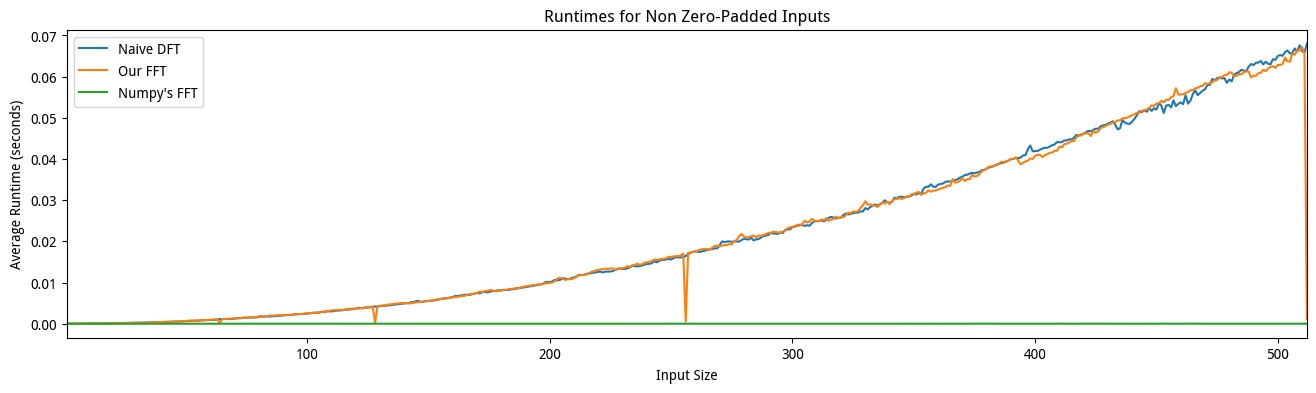

In [13]:
title = "Runtimes for Non Zero-Padded Inputs"
lab3_helper.plot_runtimes(INPUT_SIZES, dft_avg_times, my_times_3a, numpy_times_3a, title)

注意：numpy FFT 的运行时间看起来会像贴着 0 的平线。实际上它当然花费了非零时间，只是优化得太夸张，相比我们的实现几乎像瞬间完成。这也是本实验中我们实现 FFT 的主要原因：为了理解概念，而不是为了得到一个真正可用于工程的可靠版本。真实场景中，如果有成熟库函数，就用库函数。


**Q：你应该会看到 “Naive DFT” 时间和 “Our FFT” 时间基本重合，但在若干位置 “Our FFT” 会出现明显向下的尖峰。解释为什么图像会这样，以及这些向下尖峰为什么出现在那些位置。**

<span style="color:blue">A：我们的 FFT 在输入长度为 $2^N$ 时表现很好。</span>


## Q3b：补零时的性能

运行下面的单元来分析你的 FFT 函数。这一次，我们把所有输入都补零到下一个 2 的幂。
这应该不会运行太久；教师版本在 2015 年的笔记本上不到 30 秒就完成了。


In [15]:
my_times_3b = lab3_helper.get_avg_runtimes(my_fft, INPUT_SIZES, NUM_TRIALS, zero_pad=True)
numpy_times_3b = lab3_helper.get_avg_runtimes(np.fft.fft, INPUT_SIZES, NUM_TRIALS, zero_pad=True)

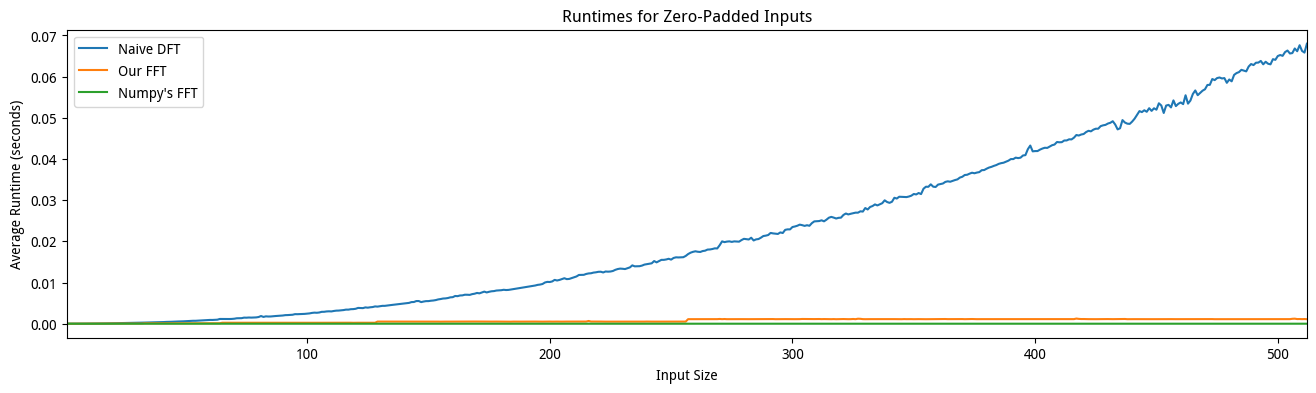

In [16]:
title = "Runtimes for Zero-Padded Inputs"
lab3_helper.plot_runtimes(INPUT_SIZES, dft_avg_times, my_times_3b, numpy_times_3b, title)

**Q：现在我们的表现看起来好多了。为什么补零会有帮助？**

<span style="color:blue">A：补零会把输入长度扩展到 2 的幂，使我们的 radix-2 FFT 可以真正使用递归分治算法，而不是在非 2 的幂长度时退回普通 DFT。因此运行时间从 $O(N^2)$ 降低到大约 $O(N\log N)$，所以速度明显变快。</span>

**Q：“Our FFT” 的图像应该看起来是分段常数。虽然它的渐近上界仍然是 $N\log N$，但为什么它是分段常数，而不是某个缩放后的 $N\log N$ 函数？**（提示：大小为 255 和 256 的输入运行时间相同吗？为什么？129、130、131、...、256 这一范围内的输入呢？）

<span style="color:blue">A： 因为补零会把输入长度补到下一个 2 的幂。这样一来，很多不同的原始输入长度会被补到同一个长度。例如，129 到 256 之间的输入都会被补到 256，因此它们实际运行的都是 256 点 FFT，运行时间几乎相同。所以图像呈现分段常数，而不是平滑的 $N\log N$ 曲线。</span>


## Q3c：分析 `numpy.fft.fft`

现在我们研究 numpy 的实现。

由于 numpy 的 FFT 比我们前面的函数快得多，小输入时很难看清相关特征，因此这里会同时增大试验次数和输入大小范围。图也会画得更高一些。

对于 Q3c，你只需要运行单元，不需要写代码，也没有概念题要回答。这些单元应该只需要几秒钟。


In [17]:
numpy_inputs = [x for x in range(1, 1025)]
numpy_times = lab3_helper.get_avg_runtimes(np.fft.fft, numpy_inputs, num_trials=100, zero_pad=False)

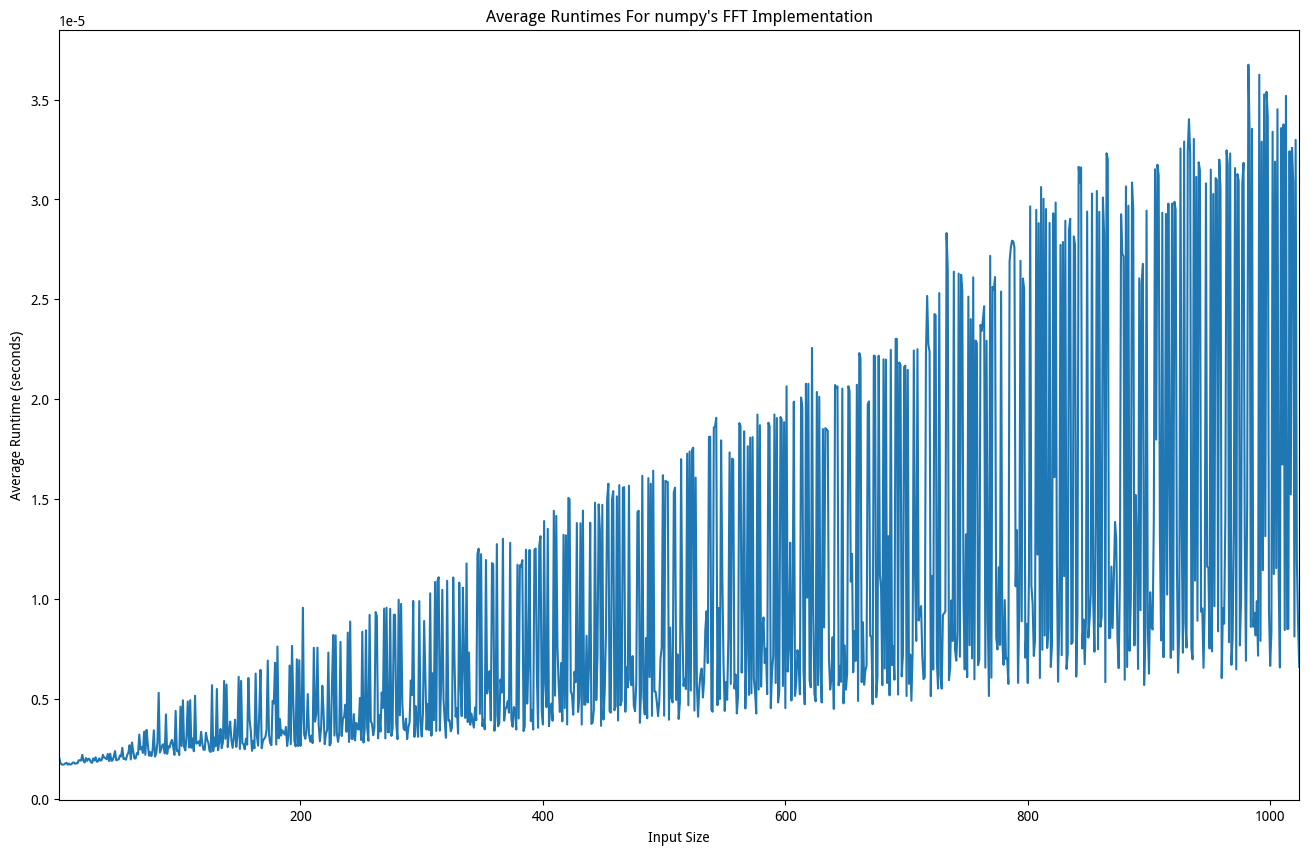

In [18]:
title = "Average Runtimes For numpy's FFT Implementation"
lab3_helper.plot_runtimes_2(numpy_inputs, numpy_times, title)

### 上面的图为什么会这样？
- 如前所述，`numpy.fft.fft` 使用的是*混合基数*方法，把适用于不同整数幂的 FFT 实现组合在一起，因此不仅能高效处理 2 的幂长度，也能高效处理多种不同长度的输入。
- 这种混合基数方法是图中尖峰的重要原因：
    - 最小值通常对应 2 或 3 的幂，因为它们容易由 radix-2 和 radix-3 算法处理。
    - 最大值通常对应质数。例如 599、601 和 607 都是质数；虽然图上很难准确读出 x 轴的值，但可以看到 600 附近有一些峰值。质数无法分解成更小的因子，也就难以用固定基数（如 radix-2、radix-3）算法帮助处理。
- 你还会看到，这个函数实际耗费的秒数相比前面那些数值非常低。除了混合基数方法外，`numpy.fft.fft` 的底层库来自 FFTW（Fastest Fourier Transform in the West），这是一个基于 FORTRAN 和 C 的数值库，自 20 世纪 70 年代以来不断发展，里面包含了几乎所有你能想到的性能优化技巧。


# Q4：高效示波器校准

你大概率不需要亲自重新实现 FFT。但是，在开发其他高效算法时——无论是否与信号与系统有关——你很可能需要把 FFT 当作构建模块来使用。本题正是这样做。具体来说，我们将实现[互相关](https://en.wikipedia.org/wiki/Cross-correlation)，并用它来校准测得的信号。

在科学实验以及任何涉及电子信号的设备测试中，*示波器*是测量信号的常用工具。你已经在 EE 16B 实验中使用过示波器，它很可能类似 [Tektronix 网站](https://www.tek.com/oscilloscope/tbs1000-digital-storage-oscilloscope)上的这一台：

<img src="./scope.jpg" alt="drawing" style="width:400px;"/>

看看右下方一排五个金属接口：前四个是示波器不同*通道*的输入端，因此可以同时测量多个信号。示波器屏幕上有三条信号曲线：黄色、蓝色和紫色，分别代表不同通道的测量结果（尽管图中没有画出接到接口上的线）。

在某些实验设置中，多个通道会因为各种原因测量同一个信号。但是，相对于某个参考通道，每个通道可能会有不同延迟，这在分析实验数据时会造成严重问题。例如，如果你想对通道 1 和通道 2 的测量结果取平均，但其中一个比另一个延迟了 100 个采样点，那么结果可能没有意义。这里我们将开发一种高效方法，用于识别一个信号相对另一个信号滞后了多少个采样点，并通过移位把信号正确对齐。


## Q4a：高斯脉冲

光学和光学工程中最常见的信号之一是*高斯脉冲*，它常用于模拟光穿过某种材料截面时，其强度随时间变化的情况。它具有经典的钟形曲线形状，只不过这里不是把它看作概率分布，而是看作幅度随时间变化的普通信号。由于高斯信号在光学中非常常见，它很适合作为我们开发算法时使用的信号。


### 半高全宽

描述对称脉冲形状时，一个非常常用的量是半高全宽（Full Width at Half Maximum，简称 FWHM）。它的意思和字面一样：在最大幅度一半处，脉冲的宽度。这个量不仅用于高斯脉冲，也用于三角脉冲、洛伦兹脉冲等其他对称脉冲。

下面是高斯脉冲 FWHM 的一个可视化示例（图片来源为 [6]）：

<img src="./FWHM.png" alt="drawing" style="width:400px;"/>

如果你学过概率论，应该见过高斯函数的形式：

$$f(t) = \frac{1}{\sqrt{2\pi}\sigma}e^{-(t - \mu)^2 / 2\sigma^2}$$

这个表达式用*标准差* $\sigma$ 来参数化高斯函数。把高斯函数看作概率密度函数时，这种写法很有用；但把它看作信号时，FWHM 往往更有用。

幸运的是，我们可以把高斯函数写成由 FWHM 参数化的形式：

$$f(t) = 2^{-\left(\frac{t}{FWHM / 2}\right)^2}$$

请使用这个公式，在下面实现 `gaussian_pulse`，生成一个高斯脉冲，并让中间样本表示时间零点。

**提示：** 我们希望 *t* 是包含 `L` 个值的一整个范围，并且中间值为 0。在 numpy 中，一个很好的写法是 `np.arange(-L // 2, L // 2)`。其中 `//` 是整数除法，能确保得到恰好 `L` 个值。如果你不确定它为什么成立，可以分别在 `L` 为奇数和偶数时手算一下。


In [19]:
import math
def gaussian_pulse(L, fwhm):
    """Returns a gaussian pulse that is L samples long with full width at half maximum of fwhm."""
    # TODO 在这里写代码——只返回信号！
    return np.power(2, -(np.arange(-L//2, L//2)*2/fwhm)**2)


现在运行下面的单元来检查你的代码。我们会用 `plt.grid` 添加网格线，方便观察。另外，公式保证最大值总是 1（在 $t=0$ 处），所以半最大值就是 0.5。至于 FWHM，网格线会很有帮助。


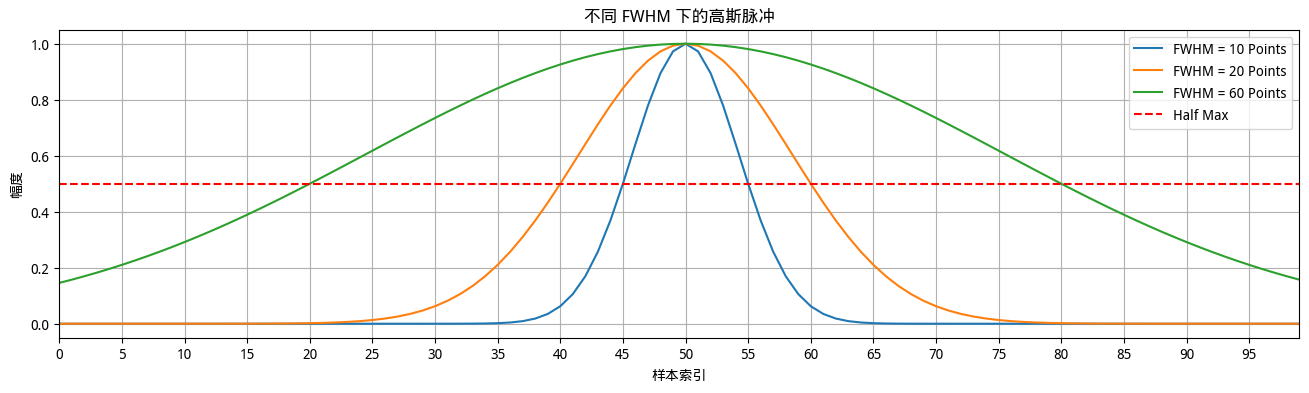

In [20]:
L = 100
FWHMs = [10, 20, 60]
plt.figure(figsize=(16, 4))
for fwhm in FWHMs:
    plt.plot(gaussian_pulse(L, fwhm))
plt.xlim([0, L-1])
plt.plot(.5 * np.ones(L), 'r--')
plt.legend(["FWHM = {0} Points".format(fwhm) for fwhm in FWHMs] + ["Half Max"])
plt.title("不同 FWHM 下的高斯脉冲")
plt.ylabel("幅度")
plt.xlabel("样本索引")
plt.xticks(np.arange(0, 100, 5))
plt.grid()
plt.show()

## 系统模型

按照示波器建模的常见方式，我们假设每个通道都有独立的延迟和噪声水平。实际中，这是因为连接到每个通道的电缆具有不同物理特性。例如，电缆长度不同会导致延迟不同：如果一根线更短，信号传播距离更短，因此到达时间更早。另外，噪声水平差异可能来自电缆磨损程度不同，也可能来自[温度的微小差异](https://en.wikipedia.org/wiki/Johnson%E2%80%93Nyquist_noise)这类更细微的因素。

我们考虑两个通道的情况；如果你有 3、4 个甚至更多通道，并希望相对于某个参考通道进行校准，原理也是一样的。所有情况下，我们把通道 1 作为参考，因此通道 1 “没有延迟”，通道 2 相对于通道 1 有某个延迟。

### 方框图

下面是我们将使用的模型的方框图表示：

<img src="./scope_model.png" alt="drawing" style="width:600px;"/>

在真实系统中，$x$ 和延迟 $d$ 都是连续时间量，延迟单位是秒而不是采样点。采样点数量形式的延迟取决于示波器采样率。不过在后处理场景中，我们只有原始数据可用，而且方法应该在不知道采样率的情况下仍然有效，因此把延迟建模为离散采样点更方便，并不会丢失信息。

在上图中：
- 我们有一个 $d$ 个采样点的延迟，用 $z^{-d}$ 模块表示。**注意 $d$ 可以小于 0，这表示通道 2 的信号比通道 1 更早到达。**
- 通道 1 测得 $y_1[n] = x[n] + z_1[n]$。
- 通道 2 测得 $y_2[n] = x[n - d] + z_2[n]$，其中 $d$ 表示通道 2 相对于通道 1 滞后的采样点数。
- $z_1,z_2$ 是叠加在信号上的加性噪声，其强度由每个通道的噪声水平决定。我们假设通道 2 的噪声比通道 1 强。具体地，我们假设噪声为*加性白高斯噪声*（AWGN），这是信号与系统中最常用的噪声模型之一。

我们的目标是找到 $d$，并在后处理中（也就是在计算机上）把 $y_2$ 向左移动 $d$ 个采样点，使测量结果正确对齐。下面已经提供了 `Oscilloscope` 类来模拟这个系统。你不需要理解它；涉及它的代码都会提供给你。


In [21]:
class Oscilloscope:
    """
    Oscilloscope modeled as a set of channels, each of which has its own delay and noise level.
    All noise is modeled as Additive White Gaussian Noise (AWGN), and delays as shifts to the right.
    """
    def __init__(self, num_channels, channel_noise_levels, channel_delays):
        """
        Parameters:
        num_channels         - The number of oscilloscope channels.
        channel_noise_levels - The standard deviation of the AWGN on each channel.
        channel_delays       - The delays, in samples, for each channel.
        
        A Value_Error is raised if num_channels does not match the number of elements of 
        channel_noise_levels and channel_delays, or if all entries of channel_delays are
        not integers.
        """
        channel_delays = np.array(channel_delays)
        if not num_channels == len(channel_noise_levels):
            raise ValueError("Number of channels must match number of noise levels provided.")
        if not num_channels == len(channel_delays):
            raise ValueError("Number of channels must match number of delays provided.")
        if not np.array_equal(channel_delays, channel_delays.astype("int")):
            raise ValueError("All delays must be integer-valued.")
        self.num_channels = num_channels
        self.channel_noise_levels = channel_noise_levels
        self.channel_delays = channel_delays
    
    def measure(self, signal):
        measurements = []
        for i in range(self.num_channels):
            curr_noise = np.random.normal(scale=self.channel_noise_levels[i], size=np.shape(signal))
            curr_channel_measurement = np.roll(signal, self.channel_delays[i]) + curr_noise
            measurements.append(curr_channel_measurement)
        return measurements

下面的单元会模拟用双通道示波器测量一个高斯脉冲。如果你以前没有用过 Python 对象，下面的代码可以让你感受我们将如何使用 `Oscilloscope` 类。


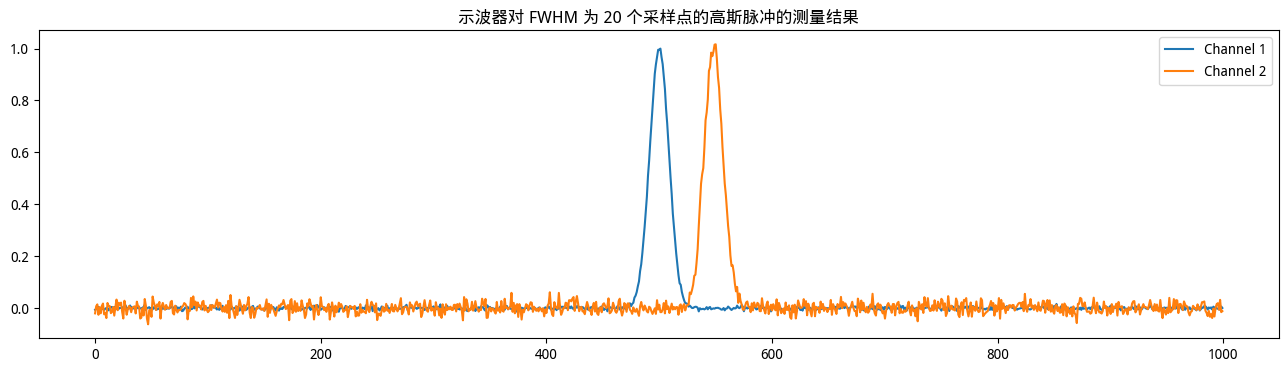

In [22]:
# 测量一个 FWHM 为 20 个采样点的高斯脉冲 
noise_levels = [.005, .02]
delays = [0, 48]
num_channels = 2
scope = Oscilloscope(num_channels, noise_levels, delays) # 构造示波器对象
signal = gaussian_pulse(1000, 20)                        # 构造待测信号
measured_signals = scope.measure(signal)                 # 调用 “measure” 方法模拟测量过程

# 显示结果
plt.figure(figsize=(16, 4))
plt.title("示波器对 FWHM 为 20 个采样点的高斯脉冲的测量结果")
plt.plot(measured_signals[0], label="Channel 1")
plt.plot(measured_signals[1], label="Channel 2")
plt.legend()
plt.show()

你应该会看到两个带噪声的高斯脉冲，它们之间有 20 个采样点的偏移。这就是真实实验设置中原始数据可能呈现的样子。我们的目标就是把这些脉冲对齐。


## 用互相关检测偏移

现在我们已经熟悉了问题设置，接下来需要一种求解方法。幸运的是，有一种非常鲁棒的方法可以做到这一点，而且你在 EE 16A 中已经接触过：互相关。在实现之前，我们先从 EE 120 的角度简要回顾它。


### EE 120 视角下的互相关

两个信号 $x$ 和 $y$ 的互相关在信号处理文献中通常记为 $R_{xy}$，定义为

$$R_{xy}[n] = \sum_{k=-\infty}^{\infty} x[k+n]y[k]$$

注意

$$R_{xy}[n] = \sum_{k=-\infty}^{\infty} y[k]x[n + k] = \sum_{k=-\infty}^{\infty} y[-k]x[n - k]$$

这正是 $x$ 与翻转后的 $y$ 的卷积。

事实上，这被称为*匹配滤波器*，在雷达和数字通信中广泛用于检测已知信号。在这类应用中，$y$ 可以表示某个事先已知的信号，例如用于识别消息起始位置的固定前导码，而 $x$ 是带噪测量信号。匹配滤波器会识别前导码 $y$ 在 $x$ 中的位置，从而确定消息从哪里开始。类似地，在这里我们想知道通道 2 的测量结果位于通道 1 的测量结果中的什么位置，以此确定偏移量。


### 把信号看成向量来度量相似度

为了更具体地理解“互相关可以度量相似度”这个想法，我们考虑归一化互相关，记作 $\tilde{R}_{xy}$：

$$\tilde{R}_{xy}[n] = \dfrac{\sum_{k=-\infty}^{\infty} x[k+n]y[k]}{\left(\sqrt{\sum_{k=-\infty}^{\infty} |x[k]|^2}\right) \left(\sqrt{\sum_{k=-\infty}^{\infty} |y[k]|^2}\right)}$$

这里唯一的区别是我们除以两个信号能量平方根的乘积，从而保证结果总在 -1 到 1 之间，这类似统计学中的相关系数。

对于我们在计算机上处理的有限时长信号（例如长度为 $N$），信号可以看作 $\mathbb{R}^N$ 中的向量，上式就对应于除以信号向量的范数。这种向量解释正是互相关可以作为相似度度量的来源。回忆一下，如果两个向量 $\vec{x}, \vec{y}$ 之间夹角为 $\theta$，则

$$\cos(\theta) = \dfrac{\vec{x} \cdot \vec{y}}{||\vec{x}|| \cdot ||\vec{y}||}$$

因此，如果我们像这里一样把信号限制在有限长度内，$\tilde{R}_{xy}[n]$ 就正是 $x[n+k]$ 与 $y[k]$ 之间夹角的余弦。

如前所述，$-1 \leq \cos(\theta) \leq 1$，这也对应归一化互相关的取值范围。另外，如果限制 $\theta \in [0,2\pi)$，那么 $\cos(\theta)$ 在 $\theta=0$ 时取得最大值。

所以：
- 归一化互相关 $\tilde{R}_{xy}[n]$ 越大，$\cos(\theta)$ 越大，因为它们相等。这里 $\theta$ 是把两个信号 $x,y$ 看作 $N$ 维欧氏空间中的向量时二者的夹角。
- $\cos(\theta)$ 越大，$\theta$ 越接近 0。
- 当 $\theta$ 趋近 0（也就是互相关增大）时，两个信号在 $\mathbb{R}^N$ 中越来越对齐，因为它们之间的夹角更小。因此，某个偏移下互相关值更高，就表示信号在精确的几何意义上更相似。

**这一部分的要点是：如果我们计算两个向量的互相关，那么使互相关最大的位置对应的滞后量，就是两个信号最相似时的延迟。因此，为了找到两个信号之间的偏移，我们只需要计算它们的互相关，并返回最大值所在的索引。**


## Q4b：互相关

实现函数 `xcorr`，返回两个信号 $x$ 和 $y$ 的**归一化**互相关。为了高效实现，你应该使用 FFT。可以使用 numpy 的实现，特别是下面这些函数会有用：
- [np.fft.fft](https://docs.scipy.org/doc/numpy/reference/generated/numpy.fft.fft.html)
- [np.fft.ifft](https://docs.scipy.org/doc/numpy/reference/generated/numpy.fft.ifft.html)
- [np.linalg.norm](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.norm.html)

你的实现中**不可以**使用 `np.convolve`、`np.correlate`，或任何直接计算卷积/互相关的库函数。

### DFT 相乘与 DTFT 相乘；补零

使用 FFT 计算卷积（或者这里的互相关）时有一个容易忽略的地方：两个 DFT 相乘在时域中对应的是*循环*卷积（或循环互相关），而不是线性卷积（或线性互相关）。DTFT 相乘才对应线性卷积；若要得到互相关，还需要先在时域翻转相应信号再相乘。

幸运的是，利用 DFT 计算线性卷积（或互相关）有一个简单补救办法：如果 $x$ 长度为 $N$，$y$ 长度为 $M$，就把 $x$ 和 $y$ 都补零到长度 $M+N-1$，然后通过相乘它们的 DFT 计算线性卷积（或互相关）。如果计算互相关 $R_{xy}$，还应先翻转 $y$。为什么这可行，可以在 [8] 中找到完整解释。

完成这种补零后，为了进一步提高效率，我们不妨继续补到 $M+N-1$ 之后的下一个 2 的幂。可以使用 `next_power_of_2` 函数。这不会影响互相关结果，因为我们只是给这些移位点积加入了与 0 相乘的额外项。这里会用到 [np.concatenate](https://docs.scipy.org/doc/numpy/reference/generated/numpy.concatenate.html) 和 [np.zeros](https://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros.html)。

### 将互相关居中

默认情况下，互相关的第一个值是 $x[n]$ 与 $y[n]$ 的点积；接下来互相关的前半部分对应 $1,2,3,...,N/2$ 的移位（其中 $N$ 是补零后的长度），然后才是 $-1,-2,-3,...,-N/2$ 的移位。当中间位置对应零偏移时，互相关结果更容易使用，也更容易画图和理解；这种图通常称为*相关图*（correlogram）。为此，需要把结果循环移动半个长度，函数 [np.fft.fftshift](https://docs.scipy.org/doc/numpy/reference/generated/numpy.concatenate.html) 可以做到这一点。你可以在计算互相关后调用它。这类似于画 DTFT 时采用从 $-\pi$ 到 $\pi$ 的约定，而不是从 $0$ 到 $2\pi$；这其实也是 `fftshift` 最初作为库函数出现的原因。

### 数值精度问题

最后：在返回以零延迟为中心的互相关之前，请对它调用 [np.real](https://docs.scipy.org/doc/numpy/reference/generated/numpy.real.html)。原因是由于数值精度有限，调用 `ifft` 后得到的时域结果可能含有很小（约 $10^{-10}$）的虚部，但这些虚部并不是真正结果的一部分（两个实值信号的互相关一定是实值的）。调用 `np.real` 会丢弃这些虚部。因此，这个函数只面向实信号。实际示波器测到的信号都会是实信号，所以这样没问题。

**提示：** 如果要用 FFT 实现两个信号的卷积，只需要相乘它们的 FFT，因为时域卷积对应频域相乘。这里计算互相关时情况类似但不完全相同，因为有一个信号要翻转。对一个**实值**信号（示波器数据都是实值）进行时域翻转，会对它的频谱造成什么影响？numpy 有没有方便的函数可以完成这个操作？


## 互相关算法总结

刚才读了很多内容！如果你有点晕，下面是执行摘要：
1. 计算 $L$：它是 $x$ 的长度加上 $y$ 的长度再减 1 之后的下一个 2 的幂。
2. 把 $x$ 和 $y$ 都补零到长度 $L$。
3. 计算补零后的 $x$ 和 $y$ 的 FFT。
4. 相乘这些 FFT，但在相乘**之前**，先对 $y$ 的 FFT 做一个操作，这个操作在频域中等价于翻转一个实值信号。这里故意不直接告诉你这个操作是什么，因为你需要根据 DTFT 性质想出来。不应该需要在时域做任何翻转。记住，时域信号是*实值*的。
5. 做逆 FFT。现在我们回到了时域。
6. 除以 $(||x|| \cdot ||y||)$。
7. 调用 `fftshift`。
8. 返回实部。


In [60]:
np.zeros(4)

array([0., 0., 0., 0.])

In [28]:
def next_power_of_2(n):
    """Returns the next power of 2 after and including n."""
    return 2 ** int(np.ceil(np.log2(n)))


def xcorr(x, y):
    """
    Returns the cross-correlation of x and y, padded to the next power of 2 after len(x) + len(y) - 1.
    Assumes that x, y are both real signals.
    """

    # 补零后的长度
    L = next_power_of_2(len(x) + len(y) - 1)

    # 归一化因子
    norm = np.linalg.norm(x) * np.linalg.norm(y)

    # 补零到长度 L
    x_pad = np.concatenate((x, np.zeros(L - len(x))))
    y_pad = np.concatenate((y, np.zeros(L - len(y))))

    # 频域计算互相关：X * conj(Y)
    X = np.fft.fft(x_pad)
    Y = np.fft.fft(y_pad)

    corr = np.fft.ifft(X * np.conj(Y))

    # 归一化
    corr = corr / norm

    # 把零延迟移到中间
    corr = np.fft.fftshift(corr)

    # 去掉数值误差导致的小虚部
    return np.real(corr)

运行下面的单元来测试你的 `xcorr` 函数；这些测试并不全面，但对我们的目的来说已经足够。我们不能像前面测试 FFT 那样直接与 `np.correlate` 比较，原因有两个：
- 我们对互相关进行了归一化（numpy 的没有归一化；事实上，如果你查看 [GitHub 上的源码](https://github.com/numpy/numpy/blob/master/numpy/core/numeric.py)，会发现库中有一个互相关例程，而 `np.convolve` 是通过翻转第二个参数后调用它实现的）。
- 我们把互相关补零到了下一个 2 的幂。

如果我们要写真正库级别的实现，就需要更仔细地考虑这些问题（例如增加是否补零、是否归一化等选项）。但对本实验来说，现在的实现已经足够。


In [29]:
print(np.fft.ifft(np.conjugate(np.fft.fft([1, 2, 3, 1]))))

[1.+0.j 1.+0.j 3.-0.j 2.+0.j]


In [30]:
# 测试 1： xcorr([1,2], [1,2])
test1_correct = np.array([0, .4, 1, .4])
test1_actual = xcorr([1,2], [1,2])

# 测试 2： xcorr([-1, 0, 1], [-1.5, 0.2, 1.5])
test2_correct = np.array([ 0.00000000e+00,  1.38165169e-17, -4.97792484e-01, -6.63723312e-02,
        9.95584967e-01,  6.63723312e-02, -4.97792484e-01, -1.38165169e-17])
test2_actual = xcorr([-1, 0, 1], [-1.5, 0.2, 1.5])

# 测试 3： xcorr([1,1,1,1,1], [1,2,3,2,1])
test3_correct = np.array([ 0.00000000e+00, -9.11251831e-17, -4.55625916e-17, -2.27812958e-17,
        1.02597835e-01,  3.07793506e-01,  6.15587011e-01,  8.20782682e-01,
        9.23380517e-01,  8.20782682e-01,  6.15587011e-01,  3.07793506e-01,
        1.02597835e-01, -2.27812958e-17, -4.55625916e-17, -9.11251831e-17])
test3_actual = xcorr([1,1,1,1,1], [1,2,3,2,1])

# 测试 4： xcorr([1, 1], [3, 6, 9])
test4_correct = np.array([0.56694671, 0.94491118, 0.56694671, 0.18898224])
test4_actual = xcorr([1, 1], [3, 6, 9])

# 测试 5： cross-correlation of two gaussian pulses with different FWHMs (should give a Gaussian with a new FWHM)
sig = gaussian_pulse(50, 10)
test5_correct = gaussian_pulse(128, 14.14213)
test5_actual = xcorr(sig, sig)

print("Test 1 (same size) 通过： {}".format(np.allclose(test1_correct, test1_actual)))
print("Test 2 (same size) 通过： {}".format(np.allclose(test2_correct, test2_actual)))
print("Test 3 (same size) 通过： {}".format(np.allclose(test3_correct, test3_actual)))
print("Test 4 (different sizes) 通过： {}".format(np.allclose(test4_correct, test4_actual)))
print("Test 5 (same size) 通过： {}".format(np.allclose(test5_correct, test5_actual)))

Test 1 (same size) 通过： True
Test 2 (same size) 通过： True
Test 3 (same size) 通过： True
Test 4 (different sizes) 通过： True
Test 5 (same size) 通过： True


## Q4c：重新对齐

现在我们已经有了高效计算两个信号互相关的方法，就可以用它来找出信号之间的偏移量。请在下面实现 `opt_offset`：它接收两个信号 $x$ 和 $y$，返回它们之间的最佳偏移，也就是使互相关最大时的延迟采样数。函数 [np.argmax](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argmax.html) 会很有用。

**提示：** 我们的互相关函数是零居中的。为了找到实际延迟，需要取出互相关最大值所在的索引，并减去对应零延迟的索引（也就是中心位置）。


In [31]:
def opt_offset(x, y):
    """Returns the most likely number of samples that x lags behind y via cross-correlation."""
    # TODO 在这里写代码
    corr = xcorr(x, y)
    idx = np.argmax(corr)
    return idx - len(corr)//2
    


下面会使用更完整的测试用例，不过这里先提供几个 `opt_offset` 的快速正确性检查。如果它们中有任何一个抛出 `AssertionError`，就表示测试失败；如果没有，就说明情况不错。


In [32]:
assert(opt_offset([0, 0, 1, 0], [0, 1, 0, 0]) == 1)     # 第一个信号比第二个滞后 1 个采样点
assert(opt_offset([0, 0, 1, 0], [1, 0, 0, 0]) == 2)     # 第一个信号比第二个滞后 2 个采样点
assert(opt_offset([1, 0, 0, 0, 0], [0, 0, 0, 0, 1]) == -4) # 第一个信号比第二个提前 4 个采样点（即滞后 -4）

为了把所有内容封装成一个好用的接口，我们再写最后一个函数 `align`。它接收两个信号，找到它们之间的最佳偏移，并将第一个信号按该偏移移动，使二者对齐。只要 `opt_offset` 正常工作，这个函数应该非常简单。我们不会直接告诉你用哪个 numpy 函数来做移位，但你应该很容易在 Google 上找到。

**提示：** 得到最佳偏移后，你要按这个量向*反方向*移动。例如，考虑上面的第一个测试：`[0,0,1,0]` 比 `[0,1,0,0]` 滞后 1 个采样点，因为脉冲在第一个信号中晚到一个采样点，所以我们希望把它向*左*移动 1 个采样点。等价地，也可以把它向*右*移动 -1 个采样点。移位时请记住这一点。


In [33]:
np.roll?

Signature:       np.roll(a, shift, axis=None)
Call signature:  np.roll(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function roll at 0x7f6f4c37db10>
File:            ~/.conda/envs/EE_lab/lib/python3.14/site-packages/numpy/_core/numeric.py
Docstring:      
Roll array elements along a given axis.

Elements that roll beyond the last position are re-introduced at
the first.

Parameters
----------
a : array_like
    Input array.
shift : int or tuple of ints
    The number of places by which elements are shifted.  If a tuple,
    then `axis` must be a tuple of the same size, and each of the
    given axes is shifted by the corresponding number.  If an int
    while `axis` is a tuple of ints, then the same value is used for
    all given axes.
axis : int or tuple of ints, optional
    Axis or axes along which elements are shifted.  By default, the
    array is flattened before shifting, after which the original
    shape is restored.

Returns
-------
res : ndar

In [34]:
def align(x, x_ref):
    """Assuming x is a delayed copy of x_ref, finds the timing offset and shifts x to be aligned with x_ref."""
    # TODO 在这里写代码
    offset = opt_offset(x, x_ref)
    x_aligned = np.roll(x, -offset)
    return x_aligned


现在我们可以在一些真实信号上测试定时校准方法了！运行下面的单元，看看结果如何。


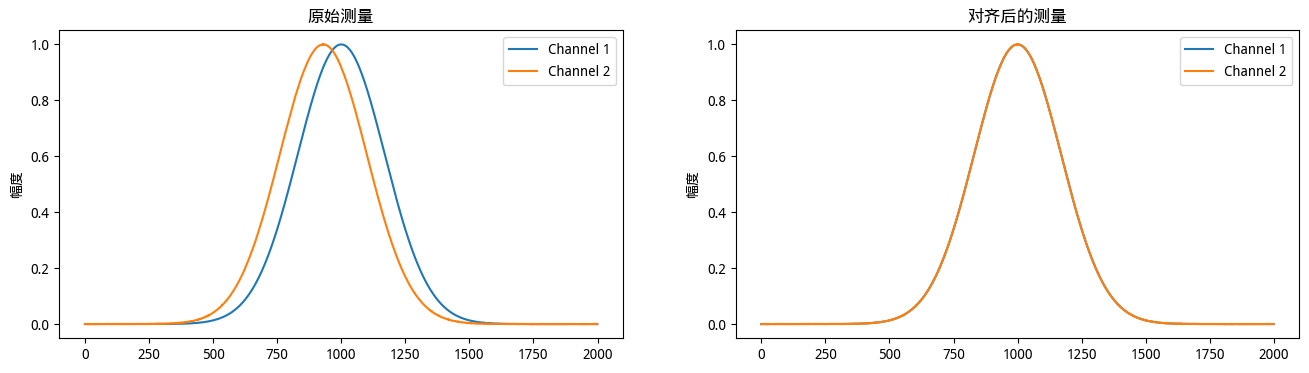

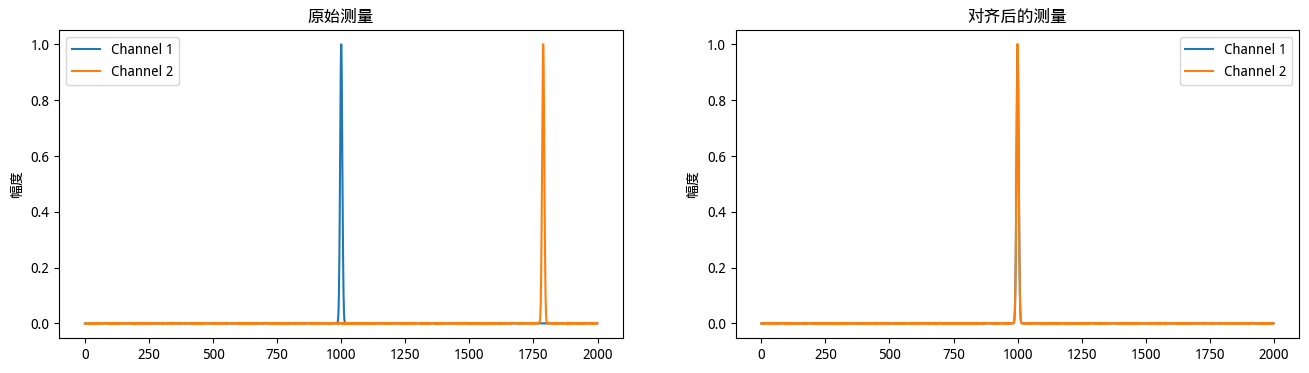

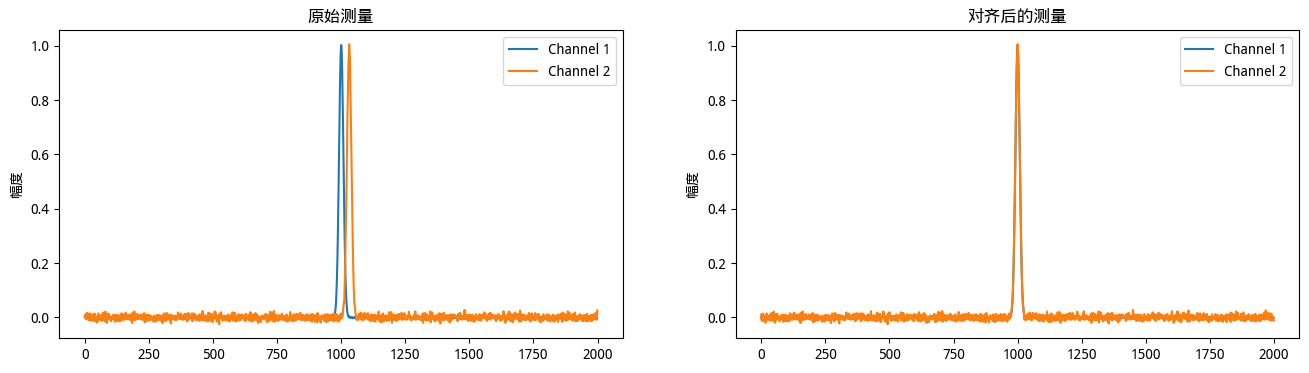

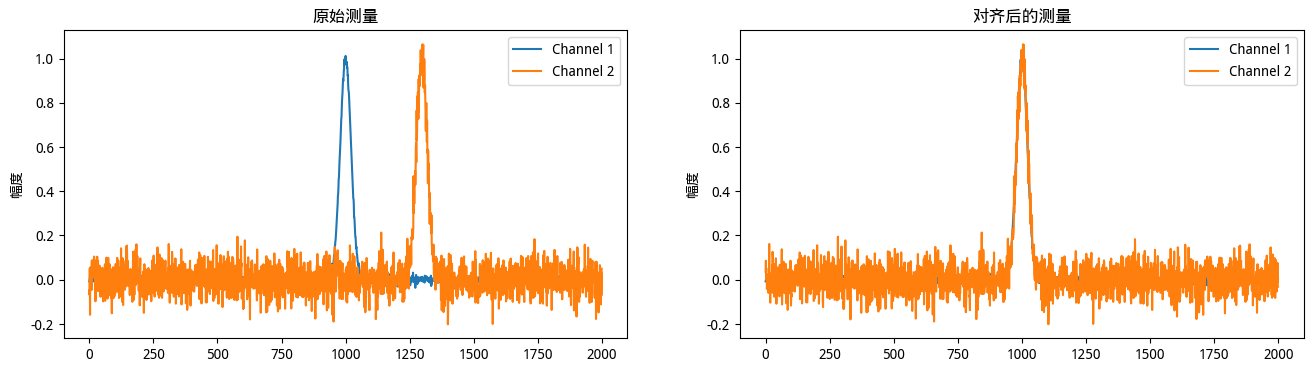

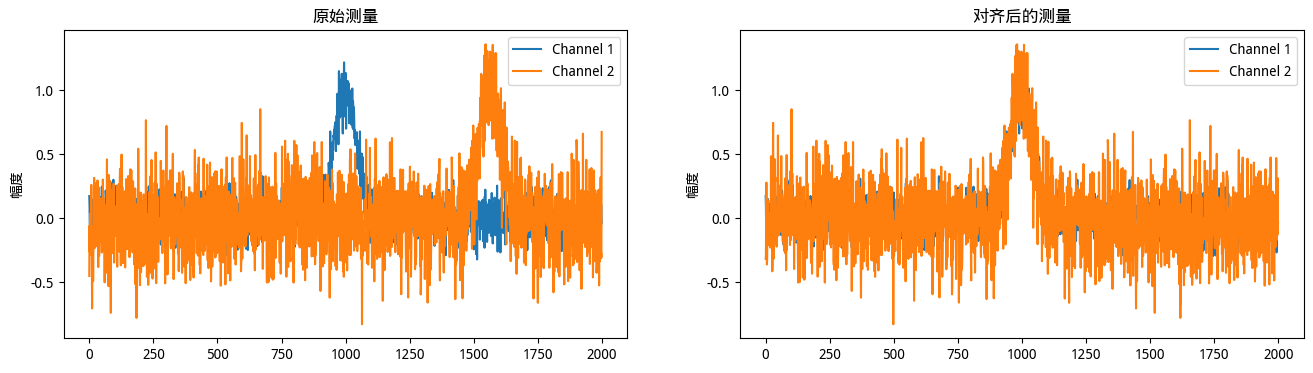

In [35]:
# 用模拟设置测试校准效果
num_channels = 2
record_length = 2000
fwhms = [400, 10, 20, 50, 100]
ch1_noise_levels = [0,     .0001, .001, .01, .1]
ch2_noise_levels = [.0003, .0009, .008, .06, .23]
ch1_delays = [0, 0, 0,  0, 0]
ch2_delays = [-70, 788, 31, 297, 563]


for i in range(len(fwhms)):
    # 构造示波器
    curr_noise_levels = [ch1_noise_levels[i], ch2_noise_levels[i]]
    curr_delays = [ch1_delays[i], ch2_delays[i]]
    scope = Oscilloscope(num_channels, curr_noise_levels, curr_delays)
    
    # 测量
    curr_signal = gaussian_pulse(record_length, fwhms[i])
    measured_signals = scope.measure(curr_signal)
    ch1_meas = measured_signals[0]
    ch2_meas = measured_signals[1]
    
    # 对齐并显示结果
    ch2_corrected = align(ch2_meas, ch1_meas)
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 2, 1)
    plt.title("原始测量")
    plt.plot(ch1_meas, label="Channel 1")
    plt.plot(ch2_meas, label="Channel 2")
    plt.ylabel("幅度")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.title("对齐后的测量")
    plt.plot(ch1_meas, label="Channel 1")
    plt.plot(ch2_corrected, label="Channel 2")
    plt.ylabel("幅度")
    plt.legend()
plt.show()

如果实现正确，你应该看到两列五行图像。第一列是“原始的”、未对齐的测量结果；第二列是调用 `align` 函数补偿延迟后的结果。如果一切正确，第二列中应该能看到对齐得很好的信号。

请注意，即使在最底下一行噪声非常强的情况下，对齐效果也仍然不错——互相关在存在加性随机噪声时检测偏移的能力非常鲁棒。（可选有趣实验：在下面新建一个单元，复用上面的代码，看看把噪声水平提高到多大时重新对齐技术会失败。由于噪声是随机的，你甚至可以多次重复实验，并经验性地估计失败概率与噪声标准差之间的关系。）


# 参考资料

[1] FFT 视频讲座。[链接](https://www.youtube.com/watch?v=1mVbZLHLaf0)   
[2] FFT（Wikipedia）。包含很好的算法推导。[链接](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm)  
[3] MIT 6.341（离散时间信号处理）关于 FFT 的笔记。[链接](https://ocw.mit.edu/courses/electrical-engineering-and-computer-science/6-341-discrete-time-signal-processing-fall-2005/lecture-notes/lec19.pdf)  
[4] EE 123 2018 春 FFT 讲义。[链接 1](https://inst.eecs.berkeley.edu/~ee123/sp18/Notes/Lecture3C.pdf)，[链接 2](https://inst.eecs.berkeley.edu/~ee123/sp18/Notes/Lecture4A.pdf)  
[5] DFT 的现代用途。[链接](http://news.mit.edu/2009/explained-fourier)  
[6] 半高全宽（Wikipedia）。[链接](https://en.wikipedia.org/wiki/Full_width_at_half_maximum)  
[7] 匹配滤波（Wikipedia）。包含多个最优性推导和示例。[链接](https://en.wikipedia.org/wiki/Matched_filter)  
[8] EE 123 2018 春 DFT 与卷积讲义。[链接](https://inst.eecs.berkeley.edu/~ee123/sp18/Notes/Lecture3B.pdf)
